# 04. Современные воспроизводимые методы

**Вопрос.** Улучшает ли моделирование последовательности прошлых попыток прогноз первого запуска нового задания по сравнению с сильным бустингом? Сравниваются DKT, AKT, UKT и TabM на тех же 108 877 обучающих и 23 326 валидационных эпизодах. Закрытый тест не используется.

DKT — воспроизведение рекуррентного принципа [Piech et al., 2015](https://arxiv.org/abs/1506.05908). AKT использует [контекстное внимание](https://arxiv.org/abs/2007.12324); UKT — [стохастические представления и Wasserstein attention, AAAI 2025](https://arxiv.org/abs/2501.05415). Для AKT/UKT используется код pyKT с зафиксированной ревизией. [TabM, ICLR 2025](https://github.com/yandex-research/tabm) — табличная модель с эффективным ансамблированием.

Это сравнение конкретных воспроизводимых методов при ограниченном бюджете, а не утверждение о полном охвате SOTA. [FA-KT, WWW 2026](https://pykt.org/fakt) использует, в частности, Mamba-эксперта; официальный CUDA-зависимый путь здесь не исполняется. Результаты для него не приписываются и превосходство над ним не утверждается.

**Единый протокол.** Три фиксированных фолда по ученикам; две скорости обучения на метод: 0,001 и 0,003 для DKT/AKT/TabM; 0,0001 и 0,001 для UKT; восемь эпох на конфигурацию; seeds 17, 42, 2026 для выбранной конфигурации. Конфигурация выбирается по объединённому OOF LogLoss. Архитектурная ширина 64 фиксирована. Это сопоставимый бюджет *внутри нейросетевого сравнения*, а не равенство FLOPs с деревьями. Все данные каждого training-fold участвуют в каждой эпохе. Промежуточные потери хранятся без вывода логов.

**Информационная граница.** История содержит префиксы последних 32 прошлых попыток, наблюдённые строго до начала текущей попытки; будущее завершение не определяет их доступность. Для KT используются только эпизоды с наблюдённым первым запуском. Текущий ответ заменён нулём и не входит в историю. Контекст концепта — сочетание шести разрешённых инструментов задания, а не размеченная компетенция. Табличная модель получает то же пространство признаков, что бустинг. Отличия входных представлений раскрываются и не трактуются как чистый эффект архитектуры.

In [1]:
from pathlib import Path
import json
import hashlib


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)

SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert "Times New Roman" in font_names
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(5))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == ["Times New Roman"]
    fig.savefig(ROOT / "figures/generated" / f"{name}.png", dpi=FIGURE_DPI)
    fig.savefig(ROOT / "figures/generated" / f"{name}.pdf", dpi=FIGURE_DPI)


import time
import io
import contextlib
import types
import random
import gc
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
import torch
from torch import nn
from torch.nn import functional as F
from tabm import TabM

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.set_num_threads(2)
SEEDS = [17, 42, 2026]
EPOCHS, BATCH_SIZE, HIDDEN_SIZE, HISTORY_LENGTH = 8, 512, 64, 32
EPSILON = 1e-6
MODEL_DIR = ROOT / "artifacts/runtime/modern"
MODEL_DIR.mkdir(exist_ok=True)
protocol = json.loads(
    (ROOT / "dataset/protocol/robomission_protocol.json").read_text()
)
verify_frozen_training_source(ROOT)
assert (
    not protocol["locked_test_opened"]
    or (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists()
)
contract = json.loads(
    (ROOT / "dataset/protocol/robo_feature_contract.json").read_text()
)
train_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_train.pkl"
).reset_index(drop=True)
validation_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_validation.pkl"
).reset_index(drop=True)
numeric_names = [
    name
    for name in contract["features"]
    if name not in contract["categorical"]
]
assert set(train_data.student).isdisjoint(validation_data.student)
curves, efficiency, predictions, tuning = [], [], [], []
selected, selected_oof = {}, {}
assert contract["feature_revision"] == "event_prefix_v2"
assert (
    train_data.attrs["feature_revision"]
    == validation_data.attrs["feature_revision"]
    == "event_prefix_v2"
)

baseline_execution = json.loads(
    (ROOT / "dataset/protocol/baseline_execution.json").read_text()
)
assert (
    baseline_execution["completed"]
    and baseline_execution["feature_revision"] == contract["feature_revision"]
)


## Представление прошлых взаимодействий

Какой объём причинно доступной истории действительно получает последовательная модель? Сводка отделяет отсутствие прошлого ответа от отрицательного ответа. Все task ID кодируются по опубликованному каталогу, без оценивания трудности на validation. Кодирование toolbox-комбинаций детерминировано метаданными.

In [2]:
problem_metadata = pd.read_pickle(
    ROOT / "dataset/processed/robo_problem_features.pkl"
)
problem_ids = sorted(problem_metadata.index.astype(int).tolist())
problem_to_index = {
    problem: index + 1 for index, problem in enumerate(problem_ids)
}
tool_columns = [
    "q_repeat",
    "q_while",
    "q_if",
    "q_if-else",
    "q_position",
    "q_shoot",
]
concept_by_problem = {
    int(problem): 1
    + sum(
        int(row[column]) * (2**bit) for bit, column in enumerate(tool_columns)
    )
    for problem, row in problem_metadata.iterrows()
}
N_TASKS, N_CONCEPTS = len(problem_ids), 65


def sequence_arrays(
    frame: pd.DataFrame, source: dict
) -> dict[str, np.ndarray]:
    """Encode observed prior interactions and a response-free current query."""
    assert source["feature_revision"] == "event_prefix_v2"
    assert np.array_equal(frame.id.to_numpy(), np.asarray(source["ids"]))
    lookup = {name: index for index, name in enumerate(source["columns"])}
    shape = (len(frame), HISTORY_LENGTH + 1)
    task = np.zeros(shape, dtype=np.int64)
    concept = np.zeros(shape, dtype=np.int64)
    response = np.zeros(shape, dtype=np.int64)
    position = np.zeros(len(frame), dtype=np.int64)
    for index, (history, current_problem) in enumerate(
        zip(source["sequences"], frame.problem)
    ):
        observed = [
            row for row in history if row[lookup["first_observed"]] == 1
        ][-HISTORY_LENGTH:]
        position[index] = len(observed)
        for step, row in enumerate(observed):
            previous_problem = int(row[lookup["problem"]])
            task[index, step] = problem_to_index[previous_problem]
            concept[index, step] = concept_by_problem[previous_problem]
            response[index, step] = int(row[lookup["first_correct"]])
        task[index, len(observed)] = problem_to_index[int(current_problem)]
        concept[index, len(observed)] = concept_by_problem[
            int(current_problem)
        ]
    assert np.all(response[np.arange(len(frame)), position] == 0)
    return {
        "task": task,
        "concept": concept,
        "response": response,
        "position": position,
    }


sequence_train = sequence_arrays(
    train_data,
    pd.read_pickle(ROOT / "dataset/processed/robo_sequences_train.pkl"),
)
sequence_validation = sequence_arrays(
    validation_data,
    pd.read_pickle(ROOT / "dataset/processed/robo_sequences_validation.pkl"),
)
representation_rows = []
for split, frame, arrays in [
    ("Train", train_data, sequence_train),
    ("Validation", validation_data, sequence_validation),
]:
    representation_rows.append(
        {
            "Split": split,
            "n": len(frame),
            "Learners": frame.student.nunique(),
            "No observed history": int((arrays["position"] == 0).sum()),
            "Median history": float(np.median(arrays["position"])),
            "At window limit": int(
                (arrays["position"] == HISTORY_LENGTH).sum()
            ),
        }
    )
table(
    pd.DataFrame(representation_rows),
    "Таблица 1. Доступная история последовательных моделей",
    "04_sequence_coverage",
)


Таблица 1. Доступная история последовательных моделей

,Split,n,Learners,No observed history,Median history,At window limit
0,Train,108877,8075,8207,8.0,3928
1,Validation,23326,1750,1783,8.0,666


## Реализации и адаптер причинного прогноза

Код AKT и UKT загружается из проверенных локальных копий pyKT (MIT), ревизия `77c3e90fdb807542194b989656ccac10e5d92e12`. В UKT удалён только неиспользуемый относительный импорт utilities; математические операции не заменяются. Конструкторский информационный print не отображается. Все исключения сохраняют обычное поведение.

В DKT скрытое состояние LSTM обновляется **только прошлыми ответами**; считывается состояние перед текущим заданием. AKT и UKT получают текущий task/concept, но предсказание обязано быть инвариантно к неизвестному текущему и будущим ответам. Для UKT сохранена contrastive loss с весом 0,02; аугментация меняет 10% прошлых ответов, не текущий. Восемь членов ансамбля TabM обучаются с отдельной BCE и усредняются на инференсе.

In [3]:
def official_module(name: str) -> types.ModuleType:
    """Load pinned upstream implementation with its provenance kept intact."""
    source = (ROOT / "notebooks/_vendor/pykt" / f"{name}.py").read_text()
    if name == "ukt":
        unused = "from .utils import transformer_FFN, ut_mask, pos_encode, get_clones\n"
        assert source.count(unused) == 1
        source = source.replace(unused, "")
    module = types.ModuleType(f"alpha_upstream_{name}")
    exec(compile(source, f"<pykt_{name}>", "exec"), module.__dict__)
    module.device = DEVICE
    return module


akt_module, ukt_module = official_module("akt"), official_module("ukt")


class DKT(nn.Module):
    """Recurrent interaction baseline with a task-specific readout."""

    def __init__(self, n_tasks: int, width: int):
        super().__init__()
        self.n_tasks = n_tasks
        self.interaction = nn.Embedding(2 * (n_tasks + 1), width)
        self.recurrent = nn.LSTM(width, width, batch_first=True)
        self.output = nn.Linear(width, n_tasks + 1)

    def forward(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        encoded = self.interaction(
            batch["task"] + (self.n_tasks + 1) * batch["response"]
        )
        states, _ = self.recurrent(encoded)
        rows = torch.arange(len(states), device=states.device)
        previous = states[rows, (batch["position"] - 1).clamp(min=0)]
        previous = previous * (batch["position"] > 0).unsqueeze(1)
        query = batch["task"][rows, batch["position"]]
        return self.output(previous)[rows, query]


def make_model(name: str, n_numeric: int = 0) -> nn.Module:
    """Construct the fixed-capacity comparator for the common training budget."""
    if name == "DKT":
        return DKT(N_TASKS, HIDDEN_SIZE).to(DEVICE)
    if name == "AKT":
        return akt_module.AKT(
            n_question=N_CONCEPTS,
            n_pid=N_TASKS,
            d_model=HIDDEN_SIZE,
            n_blocks=1,
            dropout=0.1,
            d_ff=128,
            final_fc_dim=128,
            num_attn_heads=4,
        ).to(DEVICE)
    if name == "UKT":
        with contextlib.redirect_stdout(io.StringIO()):
            model = ukt_module.UKT(
                n_question=N_CONCEPTS,
                n_pid=N_TASKS,
                d_model=HIDDEN_SIZE,
                n_blocks=1,
                dropout=0.1,
                d_ff=128,
                final_fc_dim=128,
                final_fc_dim2=64,
                num_attn_heads=4,
                seq_len=HISTORY_LENGTH + 1,
                use_CL=True,
                use_uncertainty_aug=True,
                cl_weight=0.02,
            )
        return model.to(DEVICE)
    assert name == "TabM"
    return TabM.make(
        n_num_features=n_numeric,
        cat_cardinalities=[N_TASKS + 1],
        d_out=1,
        n_blocks=2,
        d_block=HIDDEN_SIZE,
        k=8,
        dropout=0.1,
    ).to(DEVICE)


def model_output(
    model: nn.Module,
    name: str,
    batch: dict[str, torch.Tensor],
    training: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Return probabilities and training loss without observing the query answer."""
    rows = torch.arange(len(batch["position"]), device=DEVICE)
    auxiliary = torch.zeros((), device=DEVICE)
    if name == "DKT":
        logits = model(batch)
        probability = logits.sigmoid()
        loss = F.binary_cross_entropy_with_logits(logits, batch["y"])
    elif name == "TabM":
        logits = model(
            batch["numeric"],
            batch["task"][rows, batch["position"]].unsqueeze(1),
        ).squeeze(-1)
        probability = logits.sigmoid().mean(dim=1)
        loss = F.binary_cross_entropy_with_logits(
            logits, batch["y"].unsqueeze(1).expand_as(logits)
        )
    elif name == "AKT":
        all_probabilities, auxiliary = model(
            batch["concept"], batch["response"], batch["task"]
        )
        probability = all_probabilities[rows, batch["position"]]
        loss = F.binary_cross_entropy(
            probability.clamp(EPSILON, 1 - EPSILON), batch["y"]
        )
    else:
        inputs = {}
        for key, short in [("task", "q"), ("concept", "c"), ("response", "r")]:
            inputs[f"{short}seqs"] = batch[key][:, :-1]
            inputs[f"shft_{short}seqs"] = batch[key][:, 1:]
        steps = torch.arange(HISTORY_LENGTH, device=DEVICE).unsqueeze(0)
        inputs["masks"] = steps < batch["position"].unsqueeze(1)
        if training:
            augmented = batch["response"].clone()
            prior = torch.arange(HISTORY_LENGTH + 1, device=DEVICE).unsqueeze(
                0
            ) < batch["position"].unsqueeze(1)
            change = (torch.rand(augmented.shape, device=DEVICE) < 0.1) & prior
            augmented = torch.where(change, 1 - augmented, augmented)
            inputs["r_aug"], inputs["shft_r_aug"] = (
                augmented[:, :-1],
                augmented[:, 1:],
            )
            result = model(inputs, train=True)
            all_probabilities, auxiliary = result[0], 0.02 * result[1]
        else:
            all_probabilities = model(inputs)
        probability = all_probabilities[rows, batch["position"]]
        loss = F.binary_cross_entropy(
            probability.clamp(EPSILON, 1 - EPSILON), batch["y"]
        )
    return probability, loss + auxiliary


## Обучение и сохранение внефолдовых прогнозов

Импутация и масштабирование TabM обучаются заново внутри training-fold. Loss-кривые показывают ход оптимизации; результаты фолдов сохраняются вместе с идентификаторами наблюдений. Инвариантность к текущим ответам проверяется перед обучением каждого семейства. OOF после выбора настройки служит для разработки, а не независимым доказательством превосходства.

In [4]:
MODEL_LEARNING_RATES = {
    "DKT": [0.001, 0.003],
    "AKT": [0.001, 0.003],
    "UKT": [0.0001, 0.001],
    "TabM": [0.001, 0.003],
}
MODEL_DEVICES = {name: str(DEVICE) for name in MODEL_LEARNING_RATES}
# Keep the causal-invariance tolerance unchanged after an unstable MPS check.
MODEL_DEVICES["AKT"] = "cpu"
MODEL_THREADS = {name: 2 for name in MODEL_LEARNING_RATES}
CPU_THREADS = 4


def set_seed(seed: int) -> None:
    """Fix all stochastic generators used by the experimental pipeline."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "mps":
        torch.mps.manual_seed(seed)


def synchronize() -> None:
    """Synchronize asynchronous device work before timing."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()


def tensor_data(
    frame: pd.DataFrame,
    arrays: dict[str, np.ndarray],
    numeric: np.ndarray | None = None,
) -> dict[str, torch.Tensor]:
    """Move explicitly aligned inputs and supervised targets to the device."""
    result = {
        name: torch.as_tensor(values, device=DEVICE)
        for name, values in arrays.items()
    }
    result["y"] = torch.as_tensor(
        frame.y.to_numpy(dtype=np.float32), device=DEVICE
    )
    if numeric is not None:
        result["numeric"] = torch.as_tensor(
            numeric, dtype=torch.float32, device=DEVICE
        )
    return result


def subset(
    data: dict[str, torch.Tensor], indices: torch.Tensor
) -> dict[str, torch.Tensor]:
    """Take the same row subset in every input field."""
    return {name: value[indices] for name, value in data.items()}


def predict(
    model: nn.Module, name: str, data: dict[str, torch.Tensor]
) -> np.ndarray:
    """Predict aligned probabilities in bounded batches."""
    model.eval()
    output = []
    with torch.inference_mode():
        for start in range(0, len(data["y"]), BATCH_SIZE):
            batch = {
                key: value[start : start + BATCH_SIZE]
                for key, value in data.items()
            }
            probability, _ = model_output(model, name, batch)
            output.append(probability.cpu().numpy())
    result = np.concatenate(output).astype(float)
    assert np.isfinite(result).all()
    return np.clip(result, EPSILON, 1 - EPSILON)


def measures(truth: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    """Calculate the four prespecified probability and ranking metrics."""
    return {
        "LogLoss": log_loss(truth, probability),
        "AUROC": roc_auc_score(truth, probability),
        "AP": average_precision_score(truth, probability),
        "Brier": brier_score_loss(truth, probability),
    }


def fit_one(
    name: str,
    fitting: np.ndarray,
    evaluation_frame: pd.DataFrame,
    evaluation_arrays: dict[str, np.ndarray],
    learning_rate: float,
    seed: int,
    run: str,
    save: bool = False,
) -> np.ndarray:
    """Fit once using only training rows; evaluate the final fixed epoch."""
    global DEVICE
    DEVICE = torch.device(MODEL_DEVICES[name])
    akt_module.device = DEVICE
    ukt_module.device = DEVICE
    torch.set_num_threads(MODEL_THREADS[name])
    set_seed(seed)
    synchronize()
    started = time.perf_counter()
    fitting_frame = train_data.iloc[fitting].reset_index(drop=True)
    fitting_arrays = {
        key: value[fitting] for key, value in sequence_train.items()
    }
    preprocessing, fit_numeric, eval_numeric = None, None, None
    if name == "TabM":
        preprocessing = make_pipeline(
            SimpleImputer(strategy="median", add_indicator=True),
            StandardScaler(),
        )
        fit_numeric = preprocessing.fit_transform(
            fitting_frame[numeric_names]
        ).astype(np.float32)
        eval_numeric = preprocessing.transform(
            evaluation_frame[numeric_names]
        ).astype(np.float32)
    fit_inputs = tensor_data(fitting_frame, fitting_arrays, fit_numeric)
    evaluation_inputs = tensor_data(
        evaluation_frame, evaluation_arrays, eval_numeric
    )
    model = make_model(
        name, 0 if fit_numeric is None else fit_numeric.shape[1]
    )
    model.eval()
    probe_indices = torch.argsort(evaluation_inputs["position"])[
        torch.linspace(0, len(evaluation_frame) - 1, 8, device=DEVICE).long()
    ]
    probe = {
        key: value[probe_indices].clone()
        for key, value in evaluation_inputs.items()
    }
    altered = {key: value.clone() for key, value in probe.items()}
    hidden = torch.arange(HISTORY_LENGTH + 1, device=DEVICE).unsqueeze(
        0
    ) >= probe["position"].unsqueeze(1)
    altered["response"][hidden] = 1 - altered["response"][hidden]
    with torch.inference_mode():
        reference, _ = model_output(model, name, probe)
        changed, _ = model_output(model, name, altered)
        assert torch.allclose(
            reference, changed, atol=1e-6, rtol=1e-5
        ), "Query response leakage"
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=1e-4
    )
    for epoch in range(1, EPOCHS + 1):
        model.train()
        permutation = torch.randperm(len(fitting), device=DEVICE)
        total_loss = 0.0
        for start in range(0, len(fitting), BATCH_SIZE):
            indices = permutation[start : start + BATCH_SIZE]
            batch = subset(fit_inputs, indices)
            optimizer.zero_grad(set_to_none=True)
            _, loss = model_output(model, name, batch, training=True)
            assert bool(
                torch.isfinite(loss).item()
            ), "Non-finite training loss"
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.detach().item() * len(indices)
        curves.append(
            {
                "Model": name,
                "Run": run,
                "Seed": seed,
                "Learning rate": learning_rate,
                "Epoch": epoch,
                "Training objective": total_loss / len(fitting),
            }
        )
        pd.DataFrame(curves).to_csv(
            ROOT / "artifacts/runtime/04_training_curves.csv", index=False
        )
    synchronize()
    training_seconds = time.perf_counter() - started
    prediction_start = time.perf_counter()
    probability = predict(model, name, evaluation_inputs)
    synchronize()
    inference_seconds = time.perf_counter() - prediction_start
    if save:
        checkpoint = MODEL_DIR / f"{name}_{seed}.pt"
        torch.save(
            {
                "state_dict": {
                    key: value.detach().cpu()
                    for key, value in model.state_dict().items()
                },
                "name": name,
                "seed": seed,
                "learning_rate": learning_rate,
                "n_numeric": (
                    0 if fit_numeric is None else fit_numeric.shape[1]
                ),
            },
            checkpoint,
        )
        joblib.dump(
            preprocessing, MODEL_DIR / f"{name}_{seed}_preprocessing.joblib"
        )
        efficiency.append(
            {
                "Model": name,
                "Split": "Validation",
                "n": len(evaluation_frame),
                "Seed": seed,
                "Train_s": training_seconds,
                "Inference_s": inference_seconds,
                "Parameters": sum(
                    parameter.numel() for parameter in model.parameters()
                ),
                "Model_MB": checkpoint.stat().st_size / 1e6,
                "Device": str(DEVICE),
            }
        )
    pd.DataFrame(curves).to_csv(
        ROOT / "artifacts/runtime/04_training_curves.csv", index=False
    )
    del model, optimizer, fit_inputs, evaluation_inputs
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    return probability


def cross_fit(name: str, rate: float, seed: int) -> np.ndarray:
    """Generate one prediction per learner-held-out training observation."""
    result = np.full(len(train_data), np.nan)
    for fold in sorted(train_data.fold.unique()):
        held_out = train_data.fold.eq(fold).to_numpy()
        fitting = np.flatnonzero(~held_out)
        frame = train_data.loc[held_out].reset_index(drop=True)
        arrays = {
            key: value[held_out] for key, value in sequence_train.items()
        }
        result[held_out] = fit_one(
            name, fitting, frame, arrays, rate, seed, f"Fold {fold}"
        )
    assert np.isfinite(result).all()
    return result


def tune_family(name: str) -> None:
    """Choose among the same two training budgets using pooled OOF LogLoss."""
    candidates = []
    for rate in MODEL_LEARNING_RATES[name]:
        probability = cross_fit(name, rate, SEEDS[0])
        candidates.append(
            (
                measures(train_data.y.to_numpy(), probability)["LogLoss"],
                rate,
                probability,
            )
        )
        tuning.append(
            {
                "Model": name,
                "Split": "Train OOF",
                "n": len(train_data),
                "Learning rate": rate,
                **measures(train_data.y.to_numpy(), probability),
            }
        )
    _, selected[name], selected_oof[name] = min(
        candidates, key=lambda item: item[0]
    )
    pd.DataFrame(tuning).to_csv(
        ROOT / "artifacts/runtime/04_tuning.csv", index=False
    )
    joblib.dump(
        {"selected": selected, "oof": selected_oof},
        ROOT / "artifacts/runtime/04_selection.joblib",
    )
    table(
        pd.DataFrame(tuning).query("Model == @name")[
            ["Model", "Split", "n", "Learning rate", "LogLoss", "Brier"]
        ],
        f"Настройка {name}: меньшее значение LogLoss предпочтительно",
        f"04_tuning_{name}",
    )


In [5]:
def profile_akt_threads() -> pd.DataFrame:
    """Measure matched CPU steps; select parallelism without reading outcomes."""
    global DEVICE
    previous_device = DEVICE
    DEVICE = torch.device("cpu")
    akt_module.device = DEVICE
    sample_index = np.argsort(sequence_train["position"])[
        np.linspace(0, len(train_data) - 1, BATCH_SIZE).astype(int)
    ]
    sample_frame = train_data.iloc[sample_index].reset_index(drop=True)
    sample_arrays = {
        name: values[sample_index] for name, values in sequence_train.items()
    }
    rows = []
    for threads in [1, 2, 4]:
        torch.set_num_threads(threads)
        set_seed(SEEDS[0])
        inputs = tensor_data(sample_frame, sample_arrays)
        model = make_model("AKT")
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=0.001, weight_decay=1e-4
        )
        model.train()
        elapsed = []
        for iteration in range(4):
            started = time.perf_counter()
            optimizer.zero_grad(set_to_none=True)
            _, loss = model_output(model, "AKT", inputs, training=True)
            assert bool(torch.isfinite(loss).item())
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            if iteration:
                elapsed.append(time.perf_counter() - started)
        rows.append(
            {
                "Model": "AKT",
                "Split": "Train profiling",
                "n": len(sample_frame),
                "CPU threads": threads,
                "Median step_s": float(np.median(elapsed)),
            }
        )
        del model, optimizer, inputs, loss
        gc.collect()
    DEVICE = previous_device
    akt_module.device = DEVICE
    torch.set_num_threads(2)
    return pd.DataFrame(rows)


cpu_profile = profile_akt_threads()
CPU_THREADS = int(
    cpu_profile.sort_values("Median step_s").iloc[0]["CPU threads"]
)
MODEL_THREADS["AKT"] = CPU_THREADS


## DKT

Рекуррентная последовательность — базовый контроль того, полезен ли порядок ответов. Настройка выполняется только на обучающей выборке с разделением учеников между фолдами.

In [6]:
tune_family("DKT")


Настройка DKT: меньшее значение LogLoss предпочтительно

,Model,Split,n,Learning rate,LogLoss,Brier
0,DKT,Train OOF,108877,0.001,0.54525,0.18439
1,DKT,Train OOF,108877,0.003,0.55710,0.18824


## AKT

Контекстное внимание и зависящее от дистанции затухание связывают текущее задание с прошлыми взаимодействиями. Настройка выполняется только на обучающей выборке с разделением учеников между фолдами.

AKT обучается на CPU: предварительная проверка на MPS однажды дала невоспроизводимое расхождение при неизменном причинном входе. Допуск причинной инвариантности не ослаблялся; математические операции официальной реализации сохранены.

In [7]:
tune_family("AKT")


Настройка AKT: меньшее значение LogLoss предпочтительно

,Model,Split,n,Learning rate,LogLoss,Brier
0,AKT,Train OOF,108877,0.001,0.54551,0.18455
1,AKT,Train OOF,108877,0.003,0.54823,0.18549


In [8]:
def profile_ukt_device() -> pd.DataFrame:
    """Compare matched training steps without using validation outcomes."""
    global DEVICE
    previous_device = DEVICE
    sample_index = np.argsort(sequence_train["position"])[
        np.linspace(0, len(train_data) - 1, BATCH_SIZE).astype(int)
    ]
    sample_frame = train_data.iloc[sample_index].reset_index(drop=True)
    sample_arrays = {
        name: values[sample_index] for name, values in sequence_train.items()
    }
    rows = []
    devices = ["cpu", "mps"] if torch.backends.mps.is_available() else ["cpu"]
    for device_name in devices:
        DEVICE = torch.device(device_name)
        ukt_module.device = DEVICE
        torch.set_num_threads(CPU_THREADS if device_name == "cpu" else 2)
        set_seed(SEEDS[0])
        inputs = tensor_data(sample_frame, sample_arrays)
        model = make_model("UKT")
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=0.0001, weight_decay=1e-4
        )
        elapsed = []
        model.train()
        for iteration in range(4):
            synchronize()
            started = time.perf_counter()
            optimizer.zero_grad(set_to_none=True)
            _, loss = model_output(model, "UKT", inputs, training=True)
            assert bool(torch.isfinite(loss).item())
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            synchronize()
            if iteration:
                elapsed.append(time.perf_counter() - started)
        rows.append(
            {
                "Model": "UKT",
                "Split": "Train profiling",
                "n": len(sample_frame),
                "Device": device_name,
                "Median step_s": float(np.median(elapsed)),
            }
        )
        del model, optimizer, inputs, loss
        gc.collect()
        if device_name == "mps":
            torch.mps.empty_cache()
    DEVICE = previous_device
    ukt_module.device = DEVICE
    torch.set_num_threads(2)
    return pd.DataFrame(rows)


device_profile = profile_ukt_device()
MODEL_DEVICES["UKT"] = (
    device_profile.sort_values("Median step_s").iloc[0].Device
)
MODEL_THREADS["UKT"] = CPU_THREADS if MODEL_DEVICES["UKT"] == "cpu" else 2


## UKT

Стохастическое представление различает среднее и ковариацию состояния. Auxiliary contrastive objective сохранён. Настройка выполняется только на обучающей выборке с разделением учеников между фолдами.

In [9]:
tune_family("UKT")


Настройка UKT: меньшее значение LogLoss предпочтительно

,Model,Split,n,Learning rate,LogLoss,Brier
0,UKT,Train OOF,108877,0.0001,0.55459,0.18797
1,UKT,Train OOF,108877,0.0010,0.54602,0.18474


## TabM

Нейросетевой ансамбль получает те же агрегированные предикторы, что сильные табличные baselines. Настройка выполняется только на обучающей выборке с разделением учеников между фолдами.

In [10]:
tune_family("TabM")


Настройка TabM: меньшее значение LogLoss предпочтительно

,Model,Split,n,Learning rate,LogLoss,Brier
0,TabM,Train OOF,108877,0.001,0.53851,0.18188
1,TabM,Train OOF,108877,0.003,0.53638,0.18101


## Повторные seeds и перенос на validation

Повторяются три seeds выбранной конфигурации; seed 17 OOF не пересчитывается. Для каждого seed отдельная модель обучается на всём train и оценивается на validation. Разброс по seeds отражает нестабильность оптимизации, а не доверительный интервал по ученикам.

In [11]:
def evaluate_selected_family(name: str) -> None:
    """Train the three selected-seed replicas and expose their individual results."""
    global metric_frame
    # Re-running one family replaces its own replicas rather than duplicating rows.
    predictions[:] = [
        frame for frame in predictions if frame.model.iloc[0] != name
    ]
    efficiency[:] = [row for row in efficiency if row["Model"] != name]
    curves[:] = [
        row
        for row in curves
        if row["Model"] != name
        or (row["Seed"] == SEEDS[0] and row["Run"] != "Full train")
    ]
    for seed in SEEDS:
        oof = (
            selected_oof[name]
            if seed == SEEDS[0]
            else cross_fit(name, selected[name], seed)
        )
        valid = fit_one(
            name,
            np.arange(len(train_data)),
            validation_data,
            sequence_validation,
            selected[name],
            seed,
            "Full train",
            save=True,
        )
        for split, frame, probability in [
            ("Train OOF", train_data, oof),
            ("Validation", validation_data, valid),
        ]:
            predictions.append(
                pd.DataFrame(
                    {
                        "id": frame.id,
                        "student": frame.student,
                        "problem": frame.problem,
                        "y": frame.y,
                        "fold": frame.fold,
                        "model": name,
                        "split": split,
                        "seed": seed,
                        "probability": probability,
                    }
                )
            )
        saved_predictions = pd.concat(predictions, ignore_index=True)
        saved_predictions.attrs["feature_revision"] = contract[
            "feature_revision"
        ]
        saved_predictions.to_pickle(
            ROOT / "artifacts/runtime/04_modern_predictions.pkl"
        )
        pd.DataFrame(efficiency).to_csv(
            ROOT / "artifacts/04_efficiency.csv", index=False
        )
    metric_rows = []
    for (model_name, split, seed), frame in pd.concat(predictions).groupby(
        ["model", "split", "seed"], sort=False
    ):
        metric_rows.append(
            {
                "Model": model_name,
                "Split": split,
                "n": len(frame),
                "Seed": seed,
                **measures(frame.y.to_numpy(), frame.probability.to_numpy()),
            }
        )
    metric_frame = pd.DataFrame(metric_rows)
    metric_frame.to_csv(
        ROOT / "artifacts/04_per_seed_metrics.csv", index=False
    )
    visible = metric_frame.loc[
        metric_frame.Model.eq(name),
        ["Model", "Split", "n", "Seed", "LogLoss", "Brier"],
    ]
    table(
        visible,
        f"{name}: отдельные seeds, LogLoss и Brier ↓",
        f"04_selected_{name}",
    )


### Выбранная конфигурация DKT: три seeds

Насколько меняются OOF- и validation-ошибки между тремя независимыми инициализациями выбранной конфигурации? Таблица показывает каждый запуск на одинаковых запросах.

In [12]:
evaluate_selected_family("DKT")


DKT: отдельные seeds, LogLoss и Brier ↓

,Model,Split,n,Seed,LogLoss,Brier
0,DKT,Train OOF,108877,17,0.54525,0.18439
1,DKT,Validation,23326,17,0.53933,0.18159
2,DKT,Train OOF,108877,42,0.54602,0.18465
3,DKT,Validation,23326,42,0.53947,0.18173
4,DKT,Train OOF,108877,2026,0.54544,0.18447
5,DKT,Validation,23326,2026,0.53893,0.18140


### Выбранная конфигурация AKT: три seeds

Насколько меняются OOF- и validation-ошибки между тремя независимыми инициализациями выбранной конфигурации? Таблица показывает каждый запуск на одинаковых запросах.

In [13]:
evaluate_selected_family("AKT")


AKT: отдельные seeds, LogLoss и Brier ↓

,Model,Split,n,Seed,LogLoss,Brier
0,AKT,Train OOF,108877,17,0.54551,0.18455
1,AKT,Validation,23326,17,0.53916,0.18167
2,AKT,Train OOF,108877,42,0.54424,0.18388
3,AKT,Validation,23326,42,0.53912,0.18183
4,AKT,Train OOF,108877,2026,0.54471,0.18433
5,AKT,Validation,23326,2026,0.54116,0.18269


### Выбранная конфигурация UKT: три seeds

Насколько меняются OOF- и validation-ошибки между тремя независимыми инициализациями выбранной конфигурации? Таблица показывает каждый запуск на одинаковых запросах.

In [15]:
evaluate_selected_family("UKT")


UKT: отдельные seeds, LogLoss и Brier ↓

,Model,Split,n,Seed,LogLoss,Brier
0,UKT,Train OOF,108877,17,0.54602,0.18474
1,UKT,Validation,23326,17,0.54040,0.18236
2,UKT,Train OOF,108877,42,0.54929,0.18552
3,UKT,Validation,23326,42,0.54238,0.18307
4,UKT,Train OOF,108877,2026,0.54724,0.18534
5,UKT,Validation,23326,2026,0.54029,0.18229


### Выбранная конфигурация TabM: три seeds

Насколько меняются OOF- и validation-ошибки между тремя независимыми инициализациями выбранной конфигурации? Таблица показывает каждый запуск на одинаковых запросах.

In [16]:
evaluate_selected_family("TabM")


TabM: отдельные seeds, LogLoss и Brier ↓

,Model,Split,n,Seed,LogLoss,Brier
0,TabM,Train OOF,108877,17,0.53638,0.18101
1,TabM,Validation,23326,17,0.53180,0.17880
2,TabM,Train OOF,108877,42,0.53695,0.18132
3,TabM,Validation,23326,42,0.53254,0.17921
4,TabM,Train OOF,108877,2026,0.53682,0.18122
5,TabM,Validation,23326,2026,0.53194,0.17874


### Сводка вероятностного качества

Средние по трём seeds и стандартное отклонение LogLoss дополняют индивидуальные результаты. Это качество отдельных запусков в среднем; качество усреднённых вероятностей на закрытом тесте оценивается отдельно в блокноте 06.

In [17]:
summary = (
    metric_frame.groupby(["Model", "Split", "n"], sort=False)
    .agg(
        LogLoss=("LogLoss", "mean"),
        Seed_SD=("LogLoss", "std"),
        Brier=("Brier", "mean"),
    )
    .reset_index()
)
table(
    summary,
    "Средние вероятностные метрики и разброс трёх seeds; ошибки ↓",
    "04_probability_quality",
)


Средние вероятностные метрики и разброс трёх seeds; ошибки ↓

,Model,Split,n,LogLoss,Seed_SD,Brier
0,DKT,Train OOF,108877,0.54557,0.00040,0.18450
1,DKT,Validation,23326,0.53924,0.00028,0.18157
2,AKT,Train OOF,108877,0.54482,0.00064,0.18425
3,AKT,Validation,23326,0.53981,0.00117,0.18206
4,UKT,Train OOF,108877,0.54752,0.00165,0.18520
5,UKT,Validation,23326,0.54102,0.00117,0.18258
6,TabM,Train OOF,108877,0.53671,0.00030,0.18119
7,TabM,Validation,23326,0.53209,0.00039,0.17892


## Различение успешных и неуспешных первых запусков

AUROC характеризует ранжирование, AP учитывает положительный класс. Эти показатели дополняют proper scoring rules и не заменяют их при выборе вероятностной модели.

In [18]:
ranking = (
    metric_frame.groupby(["Model", "Split", "n"], sort=False)
    .agg(AUROC=("AUROC", "mean"), AP=("AP", "mean"))
    .reset_index()
)
table(ranking, "Таблица 7. Ранжирование; AUROC и AP ↑", "04_ranking_quality")


Таблица 7. Ранжирование; AUROC и AP ↑

,Model,Split,n,AUROC,AP
0,DKT,Train OOF,108877,0.79030,0.72404
1,DKT,Validation,23326,0.79700,0.73290
2,AKT,Train OOF,108877,0.79106,0.72325
3,AKT,Validation,23326,0.79616,0.72831
4,UKT,Train OOF,108877,0.78916,0.71807
5,UKT,Validation,23326,0.79499,0.72899
6,TabM,Train OOF,108877,0.79808,0.73054
7,TabM,Validation,23326,0.80377,0.73730


## Динамика обучения

Убывание оптимизационного функционала необходимо для проверки работоспособности обучения, но само по себе не доказывает обобщение. Полотно содержит отдельные панели: UKT использует дополнительный член, поэтому абсолютные уровни разных функционалов нельзя напрямую сравнивать.

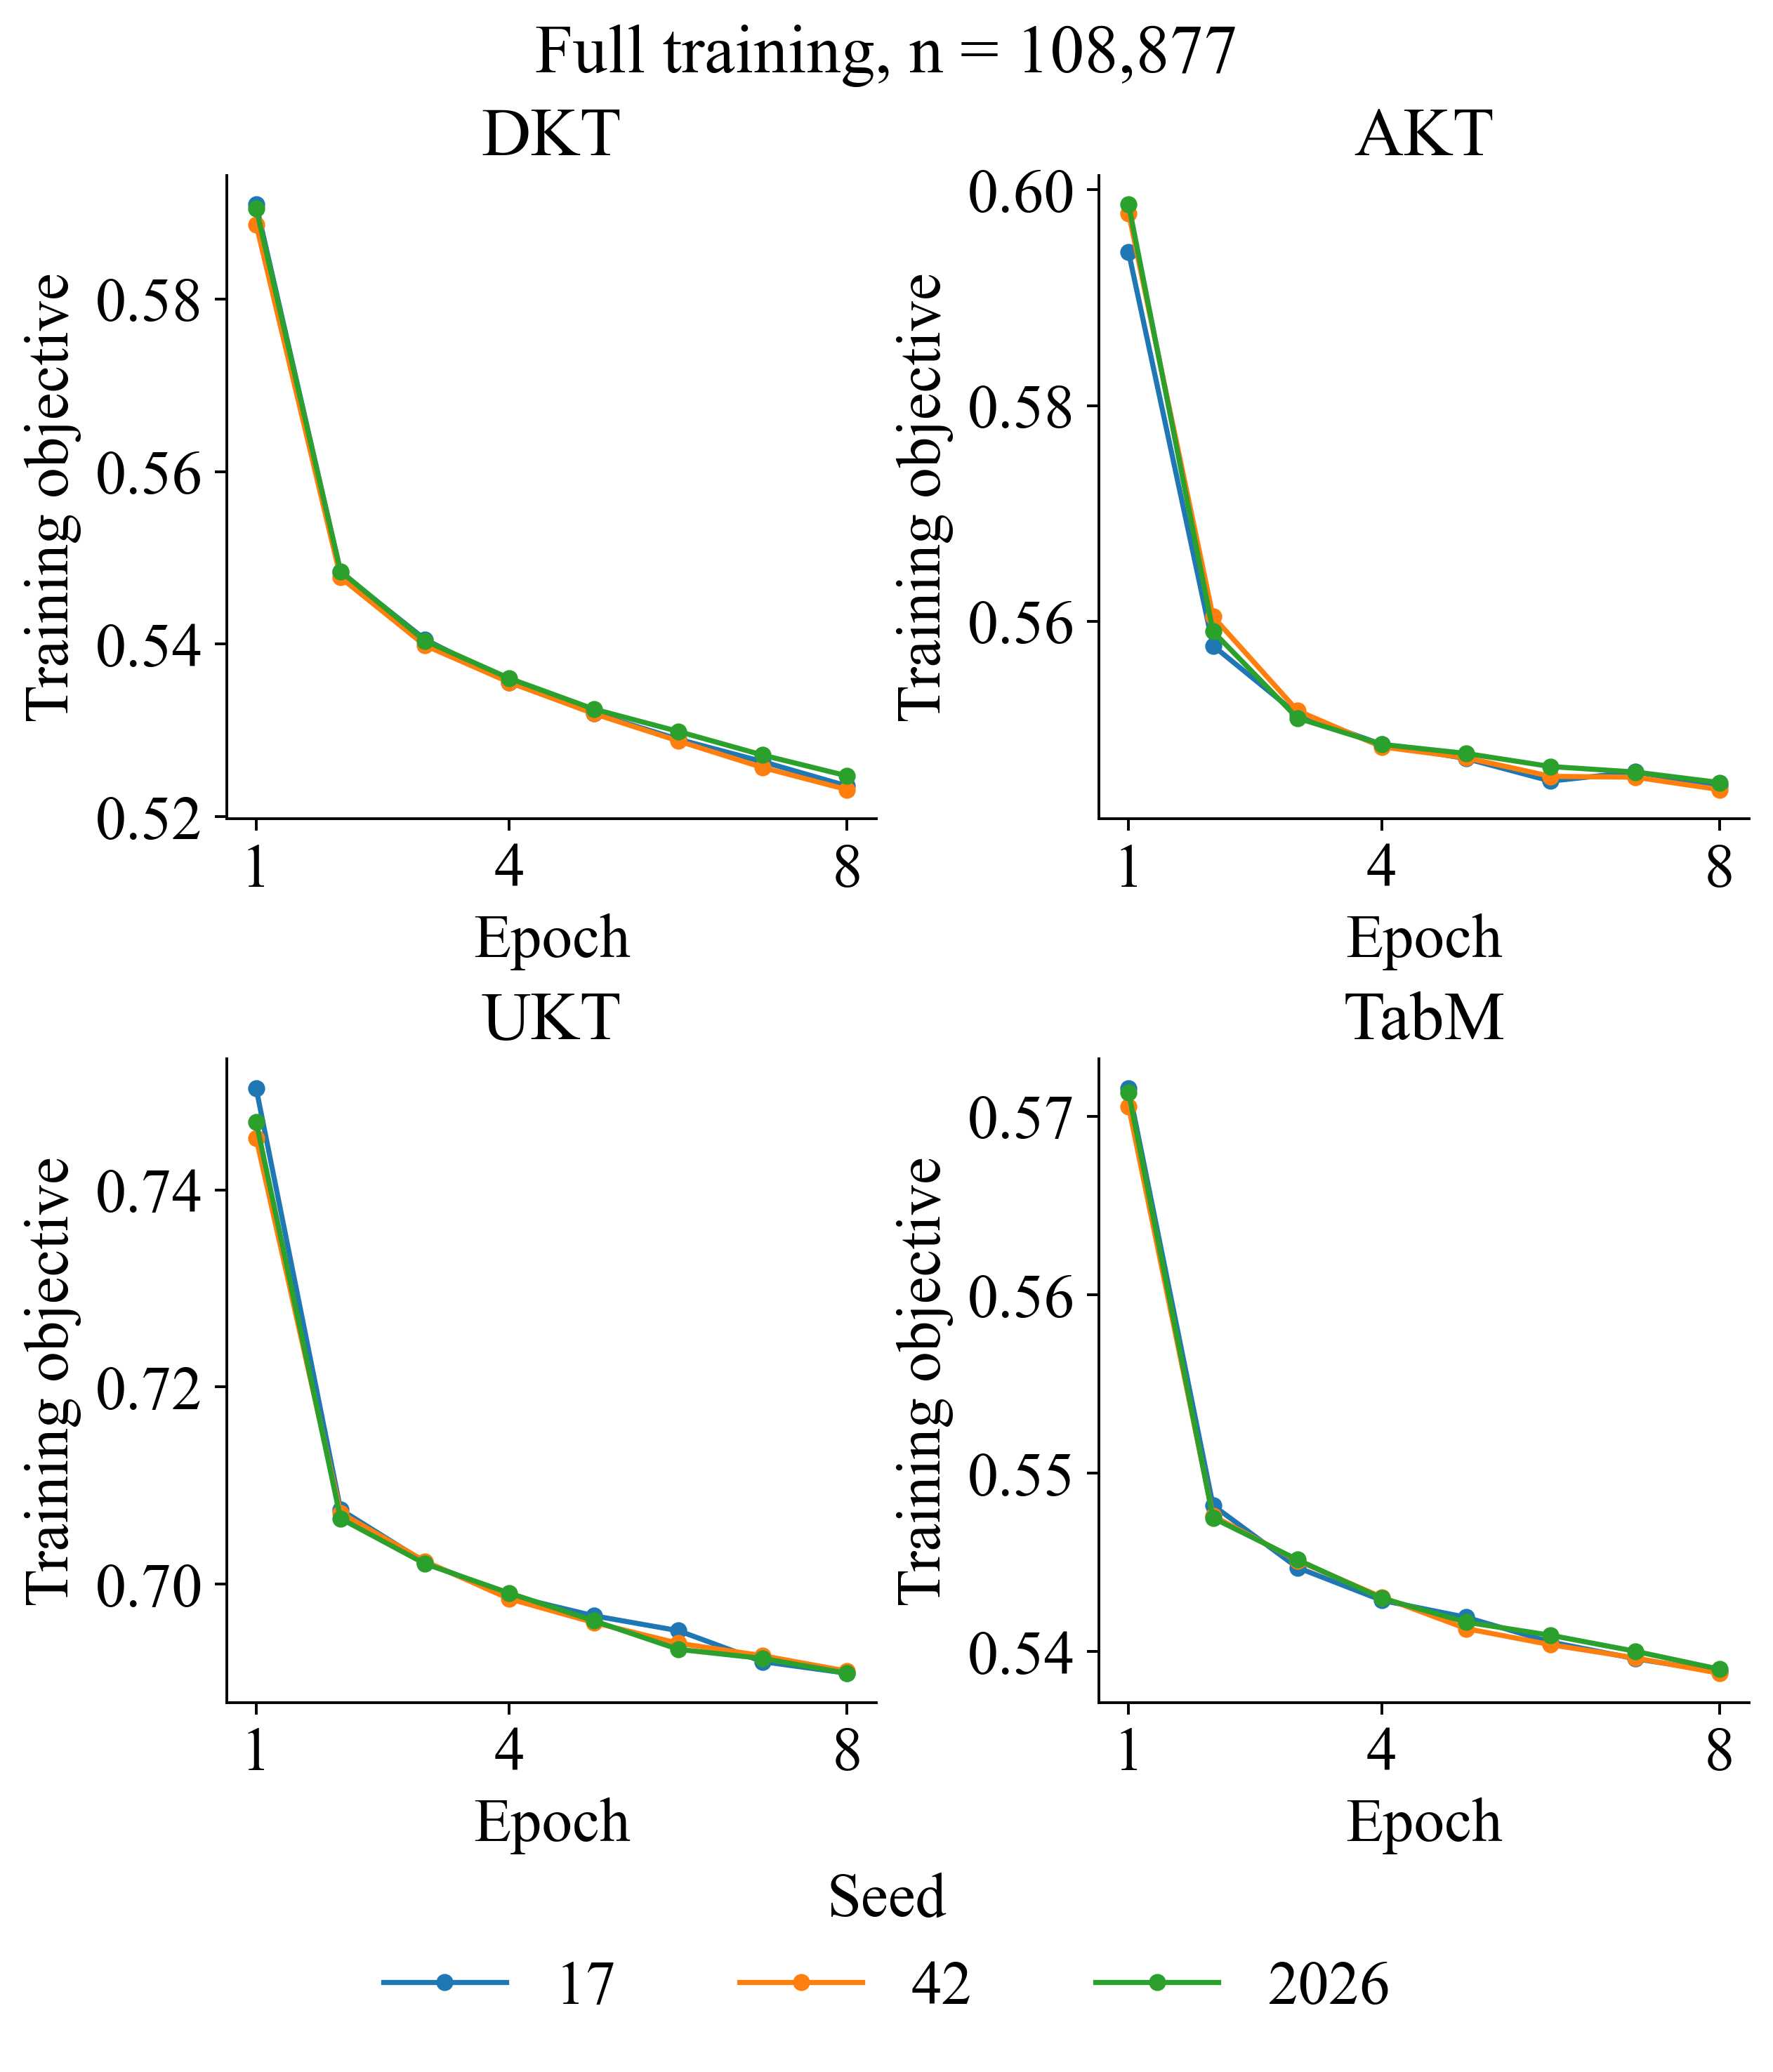

In [19]:
curve_frame = pd.DataFrame(curves)
fig, axes = plt.subplots(2, 2, figsize=(7.1, 8.4), layout="constrained")
fig.suptitle(f"Full training, n = {len(train_data):,}", fontsize=20)
for ax, name in zip(axes.flat, ["DKT", "AKT", "UKT", "TabM"]):
    selected_curves = curve_frame[
        (curve_frame.Model.eq(name)) & (curve_frame.Run.eq("Full train"))
    ]
    for seed, group in selected_curves.groupby("Seed", sort=False):
        ax.plot(
            group.Epoch,
            group["Training objective"],
            marker="o",
            markersize=4,
            label=str(seed),
        )
    ax.set(
        title=name,
        xlabel="Epoch",
        ylabel="Training objective",
        xticks=[1, 4, 8],
    )
    ax.spines[["top", "right"]].set_visible(False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Seed",
    loc="outside lower center",
    ncol=3,
    frameon=False,
)
save_figure(fig, "04_learning_curves")
plt.show()


## Сопоставление с сильными табличными методами

Сравнение использует одинаковые validation-наблюдения. Разница LogLoss вычисляется относительно лучшего ML baseline. Даже отрицательная разница здесь означает основание для разработки, а не подтверждённое тестовое превосходство.

In [20]:
baseline_metrics = pd.read_csv(ROOT / "artifacts/03_per_seed_metrics.csv")
combined = pd.concat([baseline_metrics, metric_frame], ignore_index=True)
comparison = (
    combined[combined.Split.eq("Validation")]
    .groupby(["Model", "Split", "n"], sort=False)
    .agg(
        LogLoss=("LogLoss", "mean"),
        AUROC=("AUROC", "mean"),
        AP=("AP", "mean"),
        Brier=("Brier", "mean"),
    )
    .reset_index()
)
best_ml = (
    baseline_metrics[baseline_metrics.Split.eq("Validation")]
    .groupby("Model")
    .LogLoss.mean()
    .idxmin()
)
reference = comparison[comparison.Model.eq(best_ml)].iloc[0]
comparison["Δ LogLoss"] = comparison.LogLoss - reference.LogLoss
comparison.to_csv(
    ROOT / "artifacts/runtime/04_validation_selection.csv", index=False
)
table(
    comparison[["Model", "Split", "n", "LogLoss", "Δ LogLoss"]],
    "Таблица 8. Основная метрика и отличие от сильнейшего ML",
    "04_comparison",
)


Таблица 8. Основная метрика и отличие от сильнейшего ML

,Model,Split,n,LogLoss,Δ LogLoss
0,GlobalMean,Validation,23326,0.68385,0.15311
1,ItemMean,Validation,23326,0.58900,0.05827
2,LogisticRegression,Validation,23326,0.54956,0.01882
3,RandomForest,Validation,23326,0.54154,0.01080
4,XGBoost,Validation,23326,0.53278,0.00204
5,LightGBM,Validation,23326,0.53074,0.00000
6,DKT,Validation,23326,0.53924,0.00851
7,AKT,Validation,23326,0.53981,0.00907
8,UKT,Validation,23326,0.54102,0.01029
9,TabM,Validation,23326,0.53209,0.00136


## Стоимость нейросетевых методов

Показаны медианы трёх full-train запусков. Время инференса включает формирование minibatches и перенос вероятностей с устройства, но не загрузку весов и подготовку истории. Размер checkpoint не равен пиковому потреблению памяти. Устройство сохраняется, поскольку сравнивать GPU- и CPU-время как чистый эффект архитектуры некорректно.

In [21]:
efficiency_table = (
    pd.DataFrame(efficiency)
    .groupby(["Model", "Split", "n", "Device"], sort=False)
    .agg(
        Train_s=("Train_s", "median"),
        Inference_s=("Inference_s", "median"),
        Parameters=("Parameters", "first"),
        Model_MB=("Model_MB", "median"),
    )
    .reset_index()
)
table(
    efficiency_table,
    "Таблица 9. Измеренная стоимость обучения и прогноза",
    "04_efficiency_summary",
)


Таблица 9. Измеренная стоимость обучения и прогноза

,Model,Split,n,Device,Train_s,Inference_s,Parameters,Model_MB
0,DKT,Validation,23326,mps,22.90463,0.22581,49878,0.20237
1,AKT,Validation,23326,cpu,681.69161,5.31952,154723,0.63334
2,UKT,Validation,23326,mps,874.75492,1.99146,130501,0.53248
3,TabM,Validation,23326,mps,23.36938,0.21045,18624,0.07808


## Выбор основы предлагаемой модели

Нейросетевая основа выбирается только при строгом преимуществе лучшего DL над лучшим ML по всем четырём заранее объявленным selection-метрикам; иначе основой остаётся ML. Независимо от выбора рассматривается комплементарность ошибок. Правило фиксируется до открытия теста.

In [22]:
dl_names = ["DKT", "AKT", "UKT", "TabM"]
dl_table = comparison[comparison.Model.isin(dl_names)]
best_dl = dl_table.sort_values("LogLoss", kind="stable").iloc[0]
use_dl = bool(
    best_dl.LogLoss < reference.LogLoss
    and best_dl.Brier < reference.Brier
    and best_dl.AUROC > reference.AUROC
    and best_dl.AP > reference.AP
)
decision = {
    "base": best_dl.Model if use_dl else best_ml,
    "best_ml": best_ml,
    "best_dl": best_dl.Model,
    "dl_strictly_better_all_metrics": use_dl,
    "selection_split": "Validation",
    "locked_test_opened": False,
}
(ROOT / "dataset/protocol/model_base_selection.json").write_text(
    json.dumps(decision, indent=2)
)
selected_rows = comparison[
    comparison.Model.isin([best_ml, best_dl.Model])
].copy()
selected_rows["Role"] = selected_rows.Model.map(
    lambda name: "Chosen base" if name == decision["base"] else "Comparator"
)
table(
    selected_rows[["Model", "Split", "n", "Role", "AUROC", "AP", "Brier"]],
    "Таблица 10. Дополнительные критерии выбора основы",
    "04_base_decision",
)
(ROOT / "dataset/protocol/modern_execution.json").write_text(
    json.dumps(
        {
            "feature_revision": contract["feature_revision"],
            "completed": True,
            "seeds": SEEDS,
            "devices": MODEL_DEVICES,
            "threads": MODEL_THREADS,
        }
    )
);


Таблица 10. Дополнительные критерии выбора основы

,Model,Split,n,Role,AUROC,AP,Brier
0,LightGBM,Validation,23326,Chosen base,0.80477,0.73935,0.17833
1,TabM,Validation,23326,Comparator,0.80377,0.73730,0.17892


## Ограничения

Сравнение ограничено фиксированным бюджетом, оконной историей, известным каталогом задач и конкретным архивом. Неизвестны возраст каждого пользователя и внешняя образовательная результативность. Toolbox-комбинации являются контекстом задач; они не подтверждают индивидуальное владение концептами. Выбранная на OOF настройка и validation-семья потребуют закрытой тестовой оценки. Вывод о «лучшей модели вообще» из данного эксперимента не следует.

## Совместная структура ошибок

Насколько различаются ошибки обученных семейств? Матрица показывает Pearson-корреляцию остатков $y-p$ для усреднённых по трём seeds вероятностей. Высокая корреляция ограничивает ожидаемую пользу простого ансамбля; она не доказывает отсутствие локальной комплементарности. Все модели оценены на одних и тех же validation-эпизодах. В подписях матрицы LR обозначает LogisticRegression, XGB — XGBoost, LGBM — LightGBM.

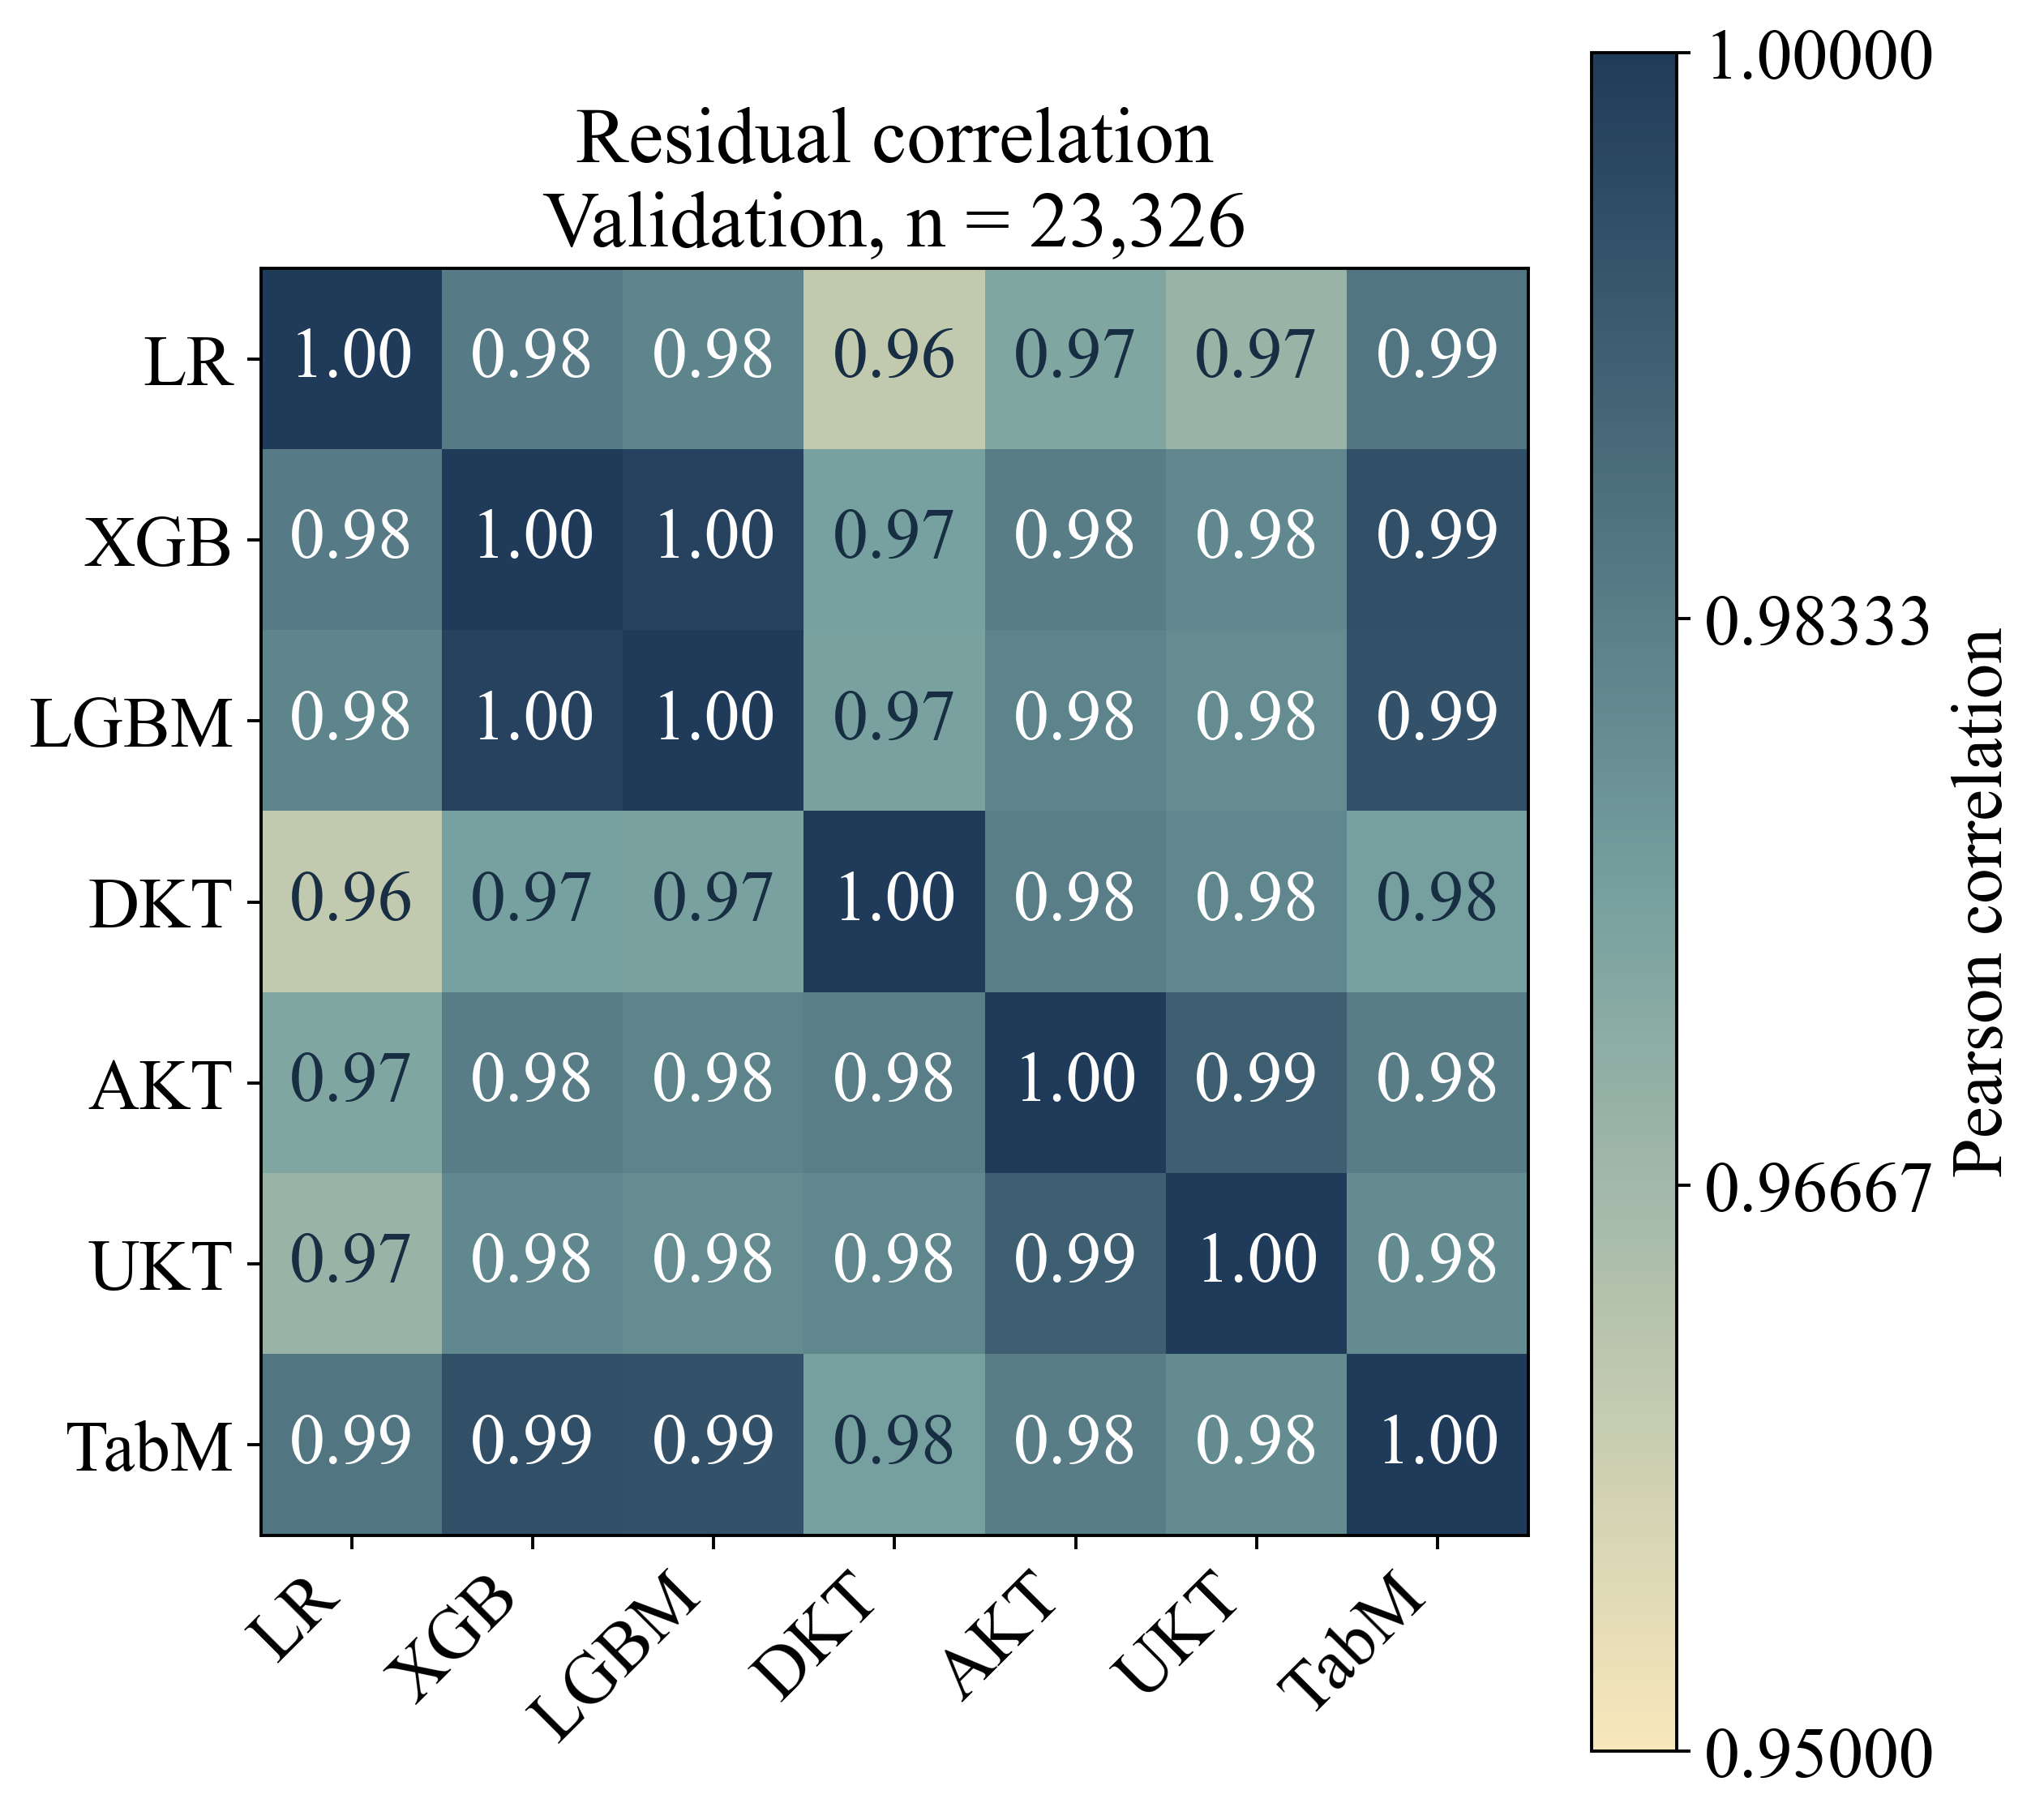

In [23]:
from matplotlib.colors import LinearSegmentedColormap

all_prediction_frame = pd.concat(
    [
        pd.read_pickle(ROOT / "artifacts/runtime/03_baseline_predictions.pkl"),
        pd.read_pickle(ROOT / "artifacts/runtime/04_modern_predictions.pkl"),
    ],
    ignore_index=True,
)
validation_predictions = all_prediction_frame[
    all_prediction_frame.split.eq("Validation")
]
probability_matrix = (
    validation_predictions.groupby(["id", "model"])
    .probability.mean()
    .unstack("model")
    .reindex(validation_data.id)
)
assert probability_matrix.notna().all().all()
error_names = [
    "LogisticRegression",
    "XGBoost",
    "LightGBM",
    "DKT",
    "AKT",
    "UKT",
    "TabM",
]
error_labels = ["LR", "XGB", "LGBM", "DKT", "AKT", "UKT", "TabM"]
residual_matrix = (
    validation_data.y.to_numpy()[:, None]
    - probability_matrix[error_names].to_numpy()
)
correlation = np.corrcoef(residual_matrix, rowvar=False)
pd.DataFrame(correlation, index=error_names, columns=error_names).to_csv(
    ROOT / "artifacts/04_residual_correlation.csv"
)
lower_color = np.floor(correlation.min() * 20) / 20
palette = LinearSegmentedColormap.from_list(
    "alpha_residuals", ["#F8E7BB", "#77A1A0", "#203B59"]
)
fig, ax = plt.subplots(figsize=(7.1, 6.3), layout="constrained")
artist = ax.imshow(correlation, cmap=palette, vmin=lower_color, vmax=1)
for row in range(len(error_names)):
    for column in range(len(error_names)):
        value = correlation[row, column]
        color = (
            "white"
            if (value - lower_color) / max(1 - lower_color, 1e-6) > 0.58
            else "#172E43"
        )
        ax.text(
            column,
            row,
            f"{value:.2f}".replace("-", "−"),
            ha="center",
            va="center",
            fontsize=18,
            color=color,
        )
ax.set_xticks(
    np.arange(len(error_names)), error_labels, rotation=45, ha="right"
)
ax.set_yticks(np.arange(len(error_names)), error_labels)
ax.set_title(f"Residual correlation\nValidation, n = {len(validation_data):,}")
fig.colorbar(
    artist,
    ax=ax,
    ticks=np.linspace(lower_color, 1, 4),
    label="Pearson correlation",
)
save_figure(fig, "04_residual_correlation")
plt.show()


## Хвост распределения индивидуальной ошибки

Как часто модель допускает большие вероятностные ошибки? Эмпирическая функция превышения LogLoss показывает весь диапазон, включая редкие уверенные ошибки. Усреднённая метрика из таблицы не заменяет эту диагностику.

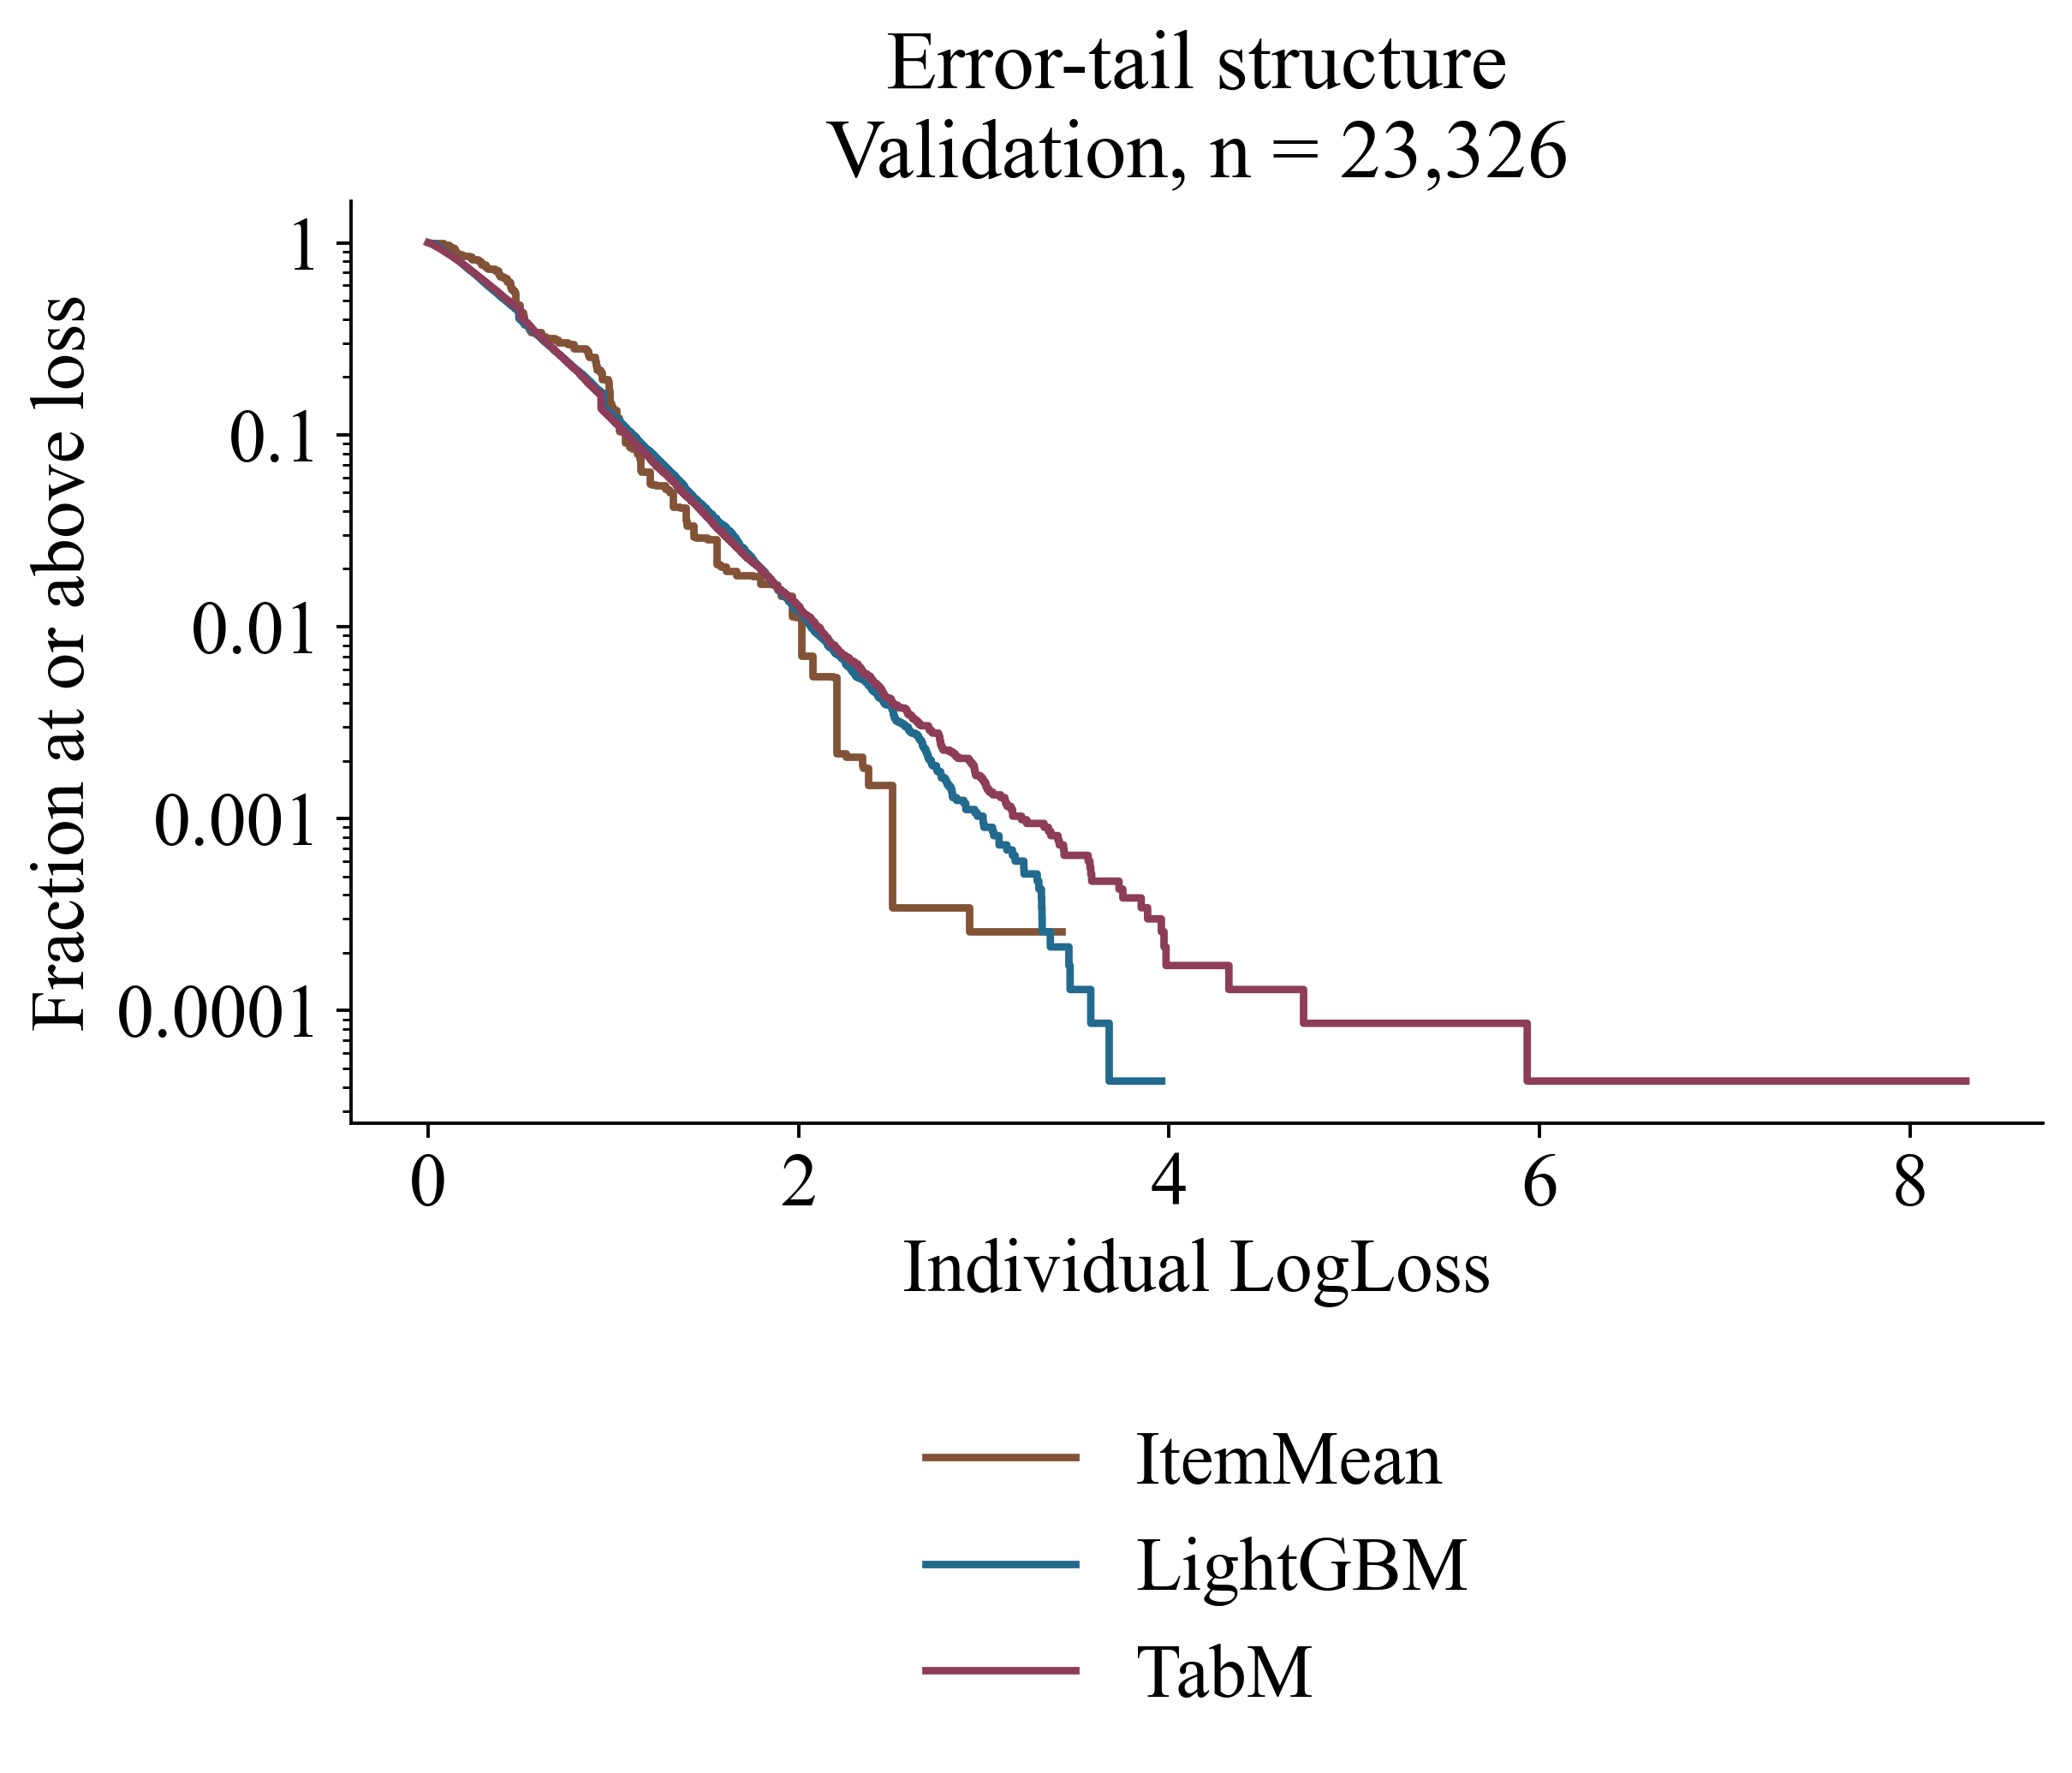

In [24]:
tail_models = ["ItemMean", best_ml, best_dl.Model]
fig, ax = plt.subplots(figsize=(6.8, 5.8), layout="constrained")
loss_curve_rows = []
for name, color in zip(tail_models, ["#825337", "#236B8E", "#8D3D58"]):
    probability = np.clip(
        probability_matrix[name].to_numpy(), EPSILON, 1 - EPSILON
    )
    truth = validation_data.y.to_numpy()
    values = np.sort(
        -(truth * np.log(probability) + (1 - truth) * np.log1p(-probability))
    )
    values, multiplicity = np.unique(values, return_counts=True)
    survival = (
        multiplicity.sum() - np.r_[0, np.cumsum(multiplicity)[:-1]]
    ) / multiplicity.sum()
    ax.step(
        values, survival, where="pre", color=color, linewidth=1.8, label=name
    )
    loss_curve_rows.append(
        pd.DataFrame(
            {"Model": name, "LogLoss": values, "Exceedance": survival}
        )
    )
ax.set_yscale("log")
ax.set_yticks(
    [1, 0.1, 0.01, 0.001, 0.0001], ["1", "0.1", "0.01", "0.001", "0.0001"]
)
ax.set(
    xlabel="Individual LogLoss",
    ylabel="Fraction at or above loss",
    title=f"Error-tail structure\nValidation, n = {len(validation_data):,}",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
pd.concat(loss_curve_rows).to_csv(
    ROOT / "artifacts/04_error_tails.csv", index=False
)
save_figure(fig, "04_error_tails")
plt.show()


## Вариация качества между групповыми фолдами

Меняется ли качество при смене удержанных учащихся? Для каждого запроса усредняются три OOF-вероятности, после чего рассчитываются ошибки отдельно внутри каждого fold. Это качество ансамбля, поэтому оно не тождественно среднему значению ошибок отдельных seeds выше. Различия folds характеризуют состав удержанной выборки; из трёх перекрывающихся обучений не выводится независимый доверительный интервал. Таблица не используется для нового подбора конфигураций.

In [25]:
fold_model_order = [
    "LogisticRegression",
    "RandomForest",
    "XGBoost",
    "LightGBM",
    "DKT",
    "AKT",
    "UKT",
    "TabM",
]
fold_prediction_source = all_prediction_frame.loc[
    all_prediction_frame.split.eq("Train OOF")
    & all_prediction_frame.model.isin(fold_model_order)
]
assert (
    fold_prediction_source.groupby(["model", "id"]).seed.nunique().eq(3).all()
)
fold_ensemble = (
    fold_prediction_source.groupby(["model", "id", "fold", "y"], sort=False)
    .probability.mean()
    .reset_index()
)
fold_rows = []
for name in fold_model_order:
    for fold in sorted(train_data.fold.unique()):
        group = fold_ensemble.loc[
            fold_ensemble.model.eq(name) & fold_ensemble.fold.eq(fold)
        ]
        assert len(group) == train_data.fold.eq(fold).sum()
        fold_rows.append(
            {
                "Model": name,
                "Split": "Train OOF",
                "Fold": int(fold),
                "n": len(group),
                "LogLoss": log_loss(group.y, group.probability),
                "Brier": brier_score_loss(group.y, group.probability),
            }
        )
fold_results = pd.DataFrame(fold_rows)
table(
    fold_results,
    "Групповые фолды; средние вероятности трёх seeds, ошибки ↓",
    "04_fold_quality",
)


Групповые фолды; средние вероятности трёх seeds, ошибки ↓

,Model,Split,Fold,n,LogLoss,Brier
0,LogisticRegression,Train OOF,0,36876,0.55243,0.18678
1,LogisticRegression,Train OOF,1,36869,0.55484,0.18793
2,LogisticRegression,Train OOF,2,35132,0.55088,0.18639
3,RandomForest,Train OOF,0,36876,0.54596,0.18409
4,RandomForest,Train OOF,1,36869,0.55034,0.18603
5,RandomForest,Train OOF,2,35132,0.54444,0.18343
6,XGBoost,Train OOF,0,36876,0.53695,0.18097
7,XGBoost,Train OOF,1,36869,0.54045,0.18252
8,XGBoost,Train OOF,2,35132,0.53379,0.17982
9,LightGBM,Train OOF,0,36876,0.53446,0.18004
